In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_PRML'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_PRML.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_PRML
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_PRML/10
    print("準備完了！このまま下のセルを実行できます。")

# 10.1 変分推論の基礎と平均場近似 (Variational Inference Foundations)

本ノートブックでは、解析的に厳密解が得られない複雑な事後分布に対する強力な決定論的近似手法である**変分推論 (Variational Inference)** を学びます。
平均場近似（因数分解変分分布）の一般解、**KLダイバージェンスの方向性による極めて対照的な挙動（ゼロ回避 vs ゼロ強制、PRML Figure 10.2, 10.3）**、および1変量ガウス分布の未知平均 $\mu$ と未知精度 $\tau$ に対する変分ベイズ反復学習の幾何学的収束過程（**PRML Figure 10.4**）を完全再現します。

## 10.1.1 変分推論の基礎と ELBO

ベイズ推論の目的は、観測データ $\mathbf{X}$ が与えられた際の潜在変数やパラメータ $\mathbf{Z}$ の事後分布 $p(\mathbf{Z}|\mathbf{X})$ を求めることです。しかし、多くの複雑なモデルでは、周辺尤度（エビデンス）$p(\mathbf{X}) = \int p(\mathbf{X}, \mathbf{Z}) d\mathbf{Z}$ の計算が解析的に実行不可能なため、真の事後分布を直接求めることは困難です。

そこで、近似分布 $q(\mathbf{Z})$ を導入し、真の事後分布 $p(\mathbf{Z}|\mathbf{X})$ に近づけることを考えます。
任意の $q(\mathbf{Z})$ に対して、周辺尤度の対数は以下のように分解できます：
$$ \ln p(\mathbf{X}) = \mathcal{L}(q) + \mathrm{KL}(q\|p) $$
ここで、各項は次のように定義されます：
$$ \mathcal{L}(q) = \int q(\mathbf{Z}) \ln \left\{ \frac{p(\mathbf{X}, \mathbf{Z})}{q(\mathbf{Z})} \right\} d\mathbf{Z} $$
$$ \mathrm{KL}(q\|p) = -\int q(\mathbf{Z}) \ln \left\{ \frac{p(\mathbf{Z}|\mathbf{X})}{q(\mathbf{Z})} \right\} d\mathbf{Z} $$

カルバック・ライブラー (KL) ダイバージェンスは常に非負（$\mathrm{KL}(q\|p) \ge 0$）であるため、$\mathcal{L}(q)$ は対数周辺尤度の下界（**エビデンス下界, Evidence Lower BOund: ELBO**）となります：
$$ \mathcal{L}(q) \le \ln p(\mathbf{X}) $$

対数エビデンス $\ln p(\mathbf{X})$ は $q(\mathbf{Z})$ に依存しない定数であるため、**下界 $\mathcal{L}(q)$ を最大化することは、KLダイバージェンス $\mathrm{KL}(q\|p)$ を最小化することと完全に等価**です。

## 平均場近似 (Mean Field Approximation) と最適更新式

近似分布 $q(\mathbf{Z})$ のクラスとして、潜在変数が互いに独立であると仮定する**因数分解近似（平均場近似）**を導入します：
$$ q(\mathbf{Z}) = \prod_{i=1}^{M} q_i(\mathbf{Z}_i) $$

この仮定のもとで、ある特定の因子 $q_j(\mathbf{Z}_j)$ 以外を固定し、$\mathcal{L}(q)$ を $q_j$ について最大化することを考えます。$\mathcal{L}(q)$ の式に因数分解の形を代入し、$q_j$ に依存する項だけを取り出すと：
$$ \mathcal{L}(q) = \int q_j(\mathbf{Z}_j) \left\{ \int \ln p(\mathbf{X}, \mathbf{Z}) \prod_{i \neq j} q_i(\mathbf{Z}_i) d\mathbf{Z}_{i \neq j} \right\} d\mathbf{Z}_j - \int q_j(\mathbf{Z}_j) \ln q_j(\mathbf{Z}_j) d\mathbf{Z}_j + \mathrm{const} $$

ここで、括弧内の項は $j$ 以外の変数に関する期待値です。新しい分布 $\ln \tilde{p}(\mathbf{X}, \mathbf{Z}_j) = \mathbb{E}_{i \neq j}[\ln p(\mathbf{X}, \mathbf{Z})] + \mathrm{const}$ を定義すると、
$$ \mathcal{L}(q) = \int q_j(\mathbf{Z}_j) \ln \frac{\tilde{p}(\mathbf{X}, \mathbf{Z}_j)}{q_j(\mathbf{Z}_j)} d\mathbf{Z}_j + \mathrm{const} = -\mathrm{KL}(q_j \| \tilde{p}) + \mathrm{const} $$

したがって、これを最大化する最適な分布 $q_j^*(\mathbf{Z}_j)$ は、負のKLダイバージェンスを最大化する（すなわちゼロにする）とき得られます。結果として、**最適な座標更新（Coordinate Ascent）式**が導かれます：
$$ \ln q_j^*(\mathbf{Z}_j) = \mathbb{E}_{i \neq j}[\ln p(\mathbf{X}, \mathbf{Z})] + \mathrm{const} $$
この式は、変分推論における最も重要な基礎方程式です。他の全ての潜在変数について対数同時確率の期待値をとり、それを正規化することで、最適な $q_j$ が得られます。

## 10.1.2 因数分解近似の性質と KL ダイバージェンスの方向性 (PRML Figure 10.2)

真の分布 $p(\mathbf{z})$ を因数分解分布 $q(\mathbf{z}) = \prod_i q_i(z_i)$ で近似するとき、最小化するKLの向きによって全く異なる結果を生じます。KLダイバージェンスは非対称（$\mathrm{KL}(p\|q) \neq \mathrm{KL}(q\|p)$）であるため、どちらを最小化するかで近似分布の振る舞いが変わります。

1. **$\mathrm{KL}(q \,||\, p)$ の最小化 (変分推論 / 逆KLダイバージェンス)**:
   $$ \mathrm{KL}(q \,||\, p) = -\int q(\mathbf{z}) \ln \left\{ \frac{p(\mathbf{z})}{q(\mathbf{z})} \right\} d\mathbf{z} $$
   $p(\mathbf{z}) \approx 0$ の領域で $q(\mathbf{z}) > 0$ となると、対数項が $-\infty$ に発散し、KLが極めて大きくなります。そのため、**$q(\mathbf{z})$ は $p(\mathbf{z}) = 0$ の領域を絶対に回避します（ゼロ回避 / Zero-avoiding）**。
   その結果、多峰性分布に対しては単一の鋭いピーク（モード）に強く集中し、局所的な構造を捉える**モード探索的（mode-seeking）**な性質を持ちます。このため、**分散を過小評価**する傾向があります（PRML Figure 10.2 左）。
   変分推論では、期待値の計算が近似分布 $q(\mathbf{z})$ に関して行われるため、計算可能性（トラクタビリティ）の観点からこの逆KLダイバージェンスが用いられます。

2. **$\mathrm{KL}(p \,||\, q)$ の最小化 (期待値伝播法 / 順KLダイバージェンス)**:
   $$ \mathrm{KL}(p \,||\, q) = -\int p(\mathbf{z}) \ln \left\{ \frac{q(\mathbf{z})}{p(\mathbf{z})} \right\} d\mathbf{z} $$
   $p(\mathbf{z}) > 0$ の領域で $q(\mathbf{z}) \approx 0$ となると被積分関数が発散するため、**$p(\mathbf{z}) > 0$ の全領域を $q(\mathbf{z})$ が覆い尽くす必要があります（ゼロ強制 / Zero-forcing）**。
   この最小化は、近似分布が指数型分布族の場合、真の分布と近似分布のモーメント（平均や分散など）を一致させる**モーメント整合（moment-matching）**に相当します。
   そのため、分布全体を包括的（inclusive）に覆おうとし、全モードをカバーするため**分散を過大評価**する傾向があります（PRML Figure 10.2 右）。

Plot saved to: result/fig10_2_kl_divergence_directions.png


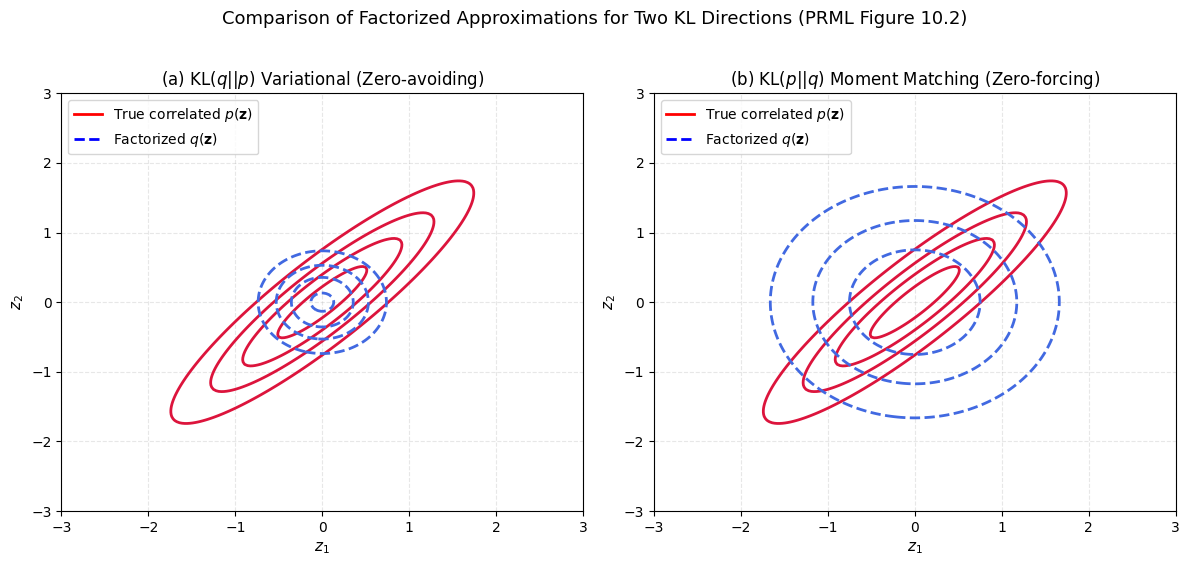

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from common.plot_utils import save_plot, setup_style
setup_style()

# 強い相関を持つ二変量ガウス真分布 p(z)
mean_p = np.array([0.0, 0.0])
cov_p = np.array([[1.0, 0.9], [0.9, 1.0]])
p_dist = multivariate_normal(mean=mean_p, cov=cov_p)
Lambda_p = np.linalg.inv(cov_p)

# 1. KL(q || p) の最適解 (PRML 式 10.13, 10.15)
# 平均は真の平均と一致: m1 = 0, m2 = 0
# 分散は精度行列の対角成分の逆数: var_i = 1 / Lambda_ii
var_q_rev = 1.0 / np.diag(Lambda_p) # 過小評価
cov_q_rev = np.diag(var_q_rev)
q_rev_dist = multivariate_normal(mean=mean_p, cov=cov_q_rev)

# 2. KL(p || q) の最適解
# モーメント整合: 平均と分散が真の周辺平均・周辺分散と完全一致
var_q_fwd = np.diag(cov_p) # [1.0, 1.0] (過大評価)
cov_q_fwd = np.diag(var_q_fwd)
q_fwd_dist = multivariate_normal(mean=mean_p, cov=cov_q_fwd)

# グリッドの作成
z1 = np.linspace(-3.0, 3.0, 200)
z2 = np.linspace(-3.0, 3.0, 200)
Z1, Z2 = np.meshgrid(z1, z2)
pos = np.dstack((Z1, Z2))

P_vals = p_dist.pdf(pos)
Q_rev_vals = q_rev_dist.pdf(pos)
Q_fwd_vals = q_fwd_dist.pdf(pos)

# PRML Figure 10.2 プロット
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

# (a) KL(q || p) - Variational Inference (Mode-seeking / Underestimation)
axes[0].contour(Z1, Z2, P_vals, levels=4, colors='crimson', linestyles='-', linewidths=2.0)
axes[0].contour(Z1, Z2, Q_rev_vals, levels=4, colors='royalblue', linestyles='--', linewidths=2.0)
axes[0].set_title(r'(a) $\mathrm{KL}(q || p)$ Variational (Zero-avoiding)', fontsize=12)
axes[0].set_xlabel('$z_1$', fontsize=11); axes[0].set_ylabel('$z_2$', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.3)
axes[0].plot([], [], 'r-', lw=2, label=r'True correlated $p(\mathbf{z})$')
axes[0].plot([], [], 'b--', lw=2, label=r'Factorized $q(\mathbf{z})$')
axes[0].legend(loc='upper left', fontsize=10)

# (b) KL(p || q) - Expectation Propagation (Moment-matching / Overestimation)
axes[1].contour(Z1, Z2, P_vals, levels=4, colors='crimson', linestyles='-', linewidths=2.0)
axes[1].contour(Z1, Z2, Q_fwd_vals, levels=4, colors='royalblue', linestyles='--', linewidths=2.0)
axes[1].set_title(r'(b) $\mathrm{KL}(p || q)$ Moment Matching (Zero-forcing)', fontsize=12)
axes[1].set_xlabel('$z_1$', fontsize=11); axes[1].set_ylabel('$z_2$', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.3)
axes[1].plot([], [], 'r-', lw=2, label=r'True correlated $p(\mathbf{z})$')
axes[1].plot([], [], 'b--', lw=2, label=r'Factorized $q(\mathbf{z})$')
axes[1].legend(loc='upper left', fontsize=10)

plt.suptitle('Comparison of Factorized Approximations for Two KL Directions (PRML Figure 10.2)', fontsize=13, y=1.02)
plt.tight_layout()
save_plot(fig, 'result', 'fig10_2_kl_divergence_directions.png')
plt.show()

## 10.1.3 1変量ガウス分布の変分ベイズ推論 (PRML Figure 10.4)

ここでは、一般的な変分推論の枠組みを具体的なモデルに適用します。
未知の平均 $\mu$ と未知の精度 $\tau$ を持つ1変量ガウス分布から、独立同分布で生成された観測データ $\mathcal{D} = \mathbf{x} = \{x_1, \dots, x_N\}$ を考えます。
尤度関数は以下のようになります：
$$ p(\mathbf{x}|\mu,\tau) = \prod_{n=1}^N \mathcal{N}(x_n|\mu,\tau^{-1}) = \left(\frac{\tau}{2\pi}\right)^{N/2} \exp\left\{ -\frac{\tau}{2} \sum_{n=1}^N (x_n - \mu)^2 \right\} $$

共役事前分布として、平均にはガウス分布、精度にはガンマ分布を導入します（ここでは一般的なPRMLのガウス・ガンマ事前分布の設定に従います）：
$$ p(\mu|\tau) = \mathcal{N}(\mu|\mu_0, (\lambda_0\tau)^{-1}) $$
$$ p(\tau) = \mathrm{Gam}(\tau|a_0,b_0) $$

### 変分事後分布の導出

事後分布 $p(\mu, \tau | \mathbf{x})$ を因数分解分布 $q(\mu, \tau) = q_\mu(\mu) q_\tau(\tau)$ で近似します。

**1. $q_\mu^*(\mu)$ の導出**
一般的な最適化式 $\ln q_\mu^*(\mu) = \mathbb{E}_{q_\tau}[\ln p(\mathbf{x}, \mu, \tau)] + \mathrm{const}$ を用います。
$$ \ln q_\mu^*(\mu) = \mathbb{E}_\tau \left[ \ln p(\mathbf{x}|\mu,\tau) + \ln p(\mu|\tau) \right] + \mathrm{const} $$
$\mu$ に依存する項だけをまとめると：
$$ \ln q_\mu^*(\mu) = -\frac{\mathbb{E}[\tau]}{2} \left\{ \sum_{n=1}^N (x_n - \mu)^2 + \lambda_0 (\mu - \mu_0)^2 \right\} + \mathrm{const} $$
これは $\mu$ に関する二次形式であり、ガウス分布となることがわかります：
$$ q_\mu^*(\mu) = \mathcal{N}(\mu | \mu_N, \lambda_N^{-1}) $$
平方完成により、パラメータは以下のように更新されます：
$$ \mu_N = \frac{\lambda_0\mu_0 + N\bar{x}}{\lambda_0 + N}, \quad \lambda_N = (\lambda_0 + N)\mathbb{E}[\tau] $$
ここで、$\bar{x}$ は標本平均です。注目すべきは、平均 $\mu_N$ が $\tau$ の期待値に依存しないため、一度計算すれば固定できる点です（ただし $\lambda_N$ は $\mathbb{E}[\tau]$ に依存します）。

**2. $q_\tau^*(\tau)$ の導出**
同様に $\ln q_\tau^*(\tau) = \mathbb{E}_{q_\mu}[\ln p(\mathbf{x}, \mu, \tau)] + \mathrm{const}$ を計算し、$\tau$ についてまとめると、ガンマ分布となります：
$$ q_\tau^*(\tau) = \mathrm{Gam}(\tau | a_N, b_N) $$
ここで、
$$ a_N = a_0 + \frac{N}{2} $$
$$ b_N = b_0 + \frac{1}{2}\mathbb{E}_\mu\left[ \sum_{n=1}^N (x_n - \mu)^2 + \lambda_0(\mu - \mu_0)^2 \right] $$

この $q_\mu^*(\mu)$ と $q_\tau^*(\tau)$ は互いのモーメント（$\mathbb{E}[\tau]$ と $\mathbb{E}[\mu], \mathbb{E}[\mu^2]$）に依存するため、交互にパラメータを更新することで、最適な近似事後分布へと段階的に改善していきます。
交互更新により、$q_\mu$ と $q_\tau$ が真の事後分布の等高線（緑）に対して最適に収束していく幾何学的様子（**PRML Figure 10.4**）を以下のコードで完全再現します。

Plot saved to: result/fig10_4_variational_gaussian_steps.png


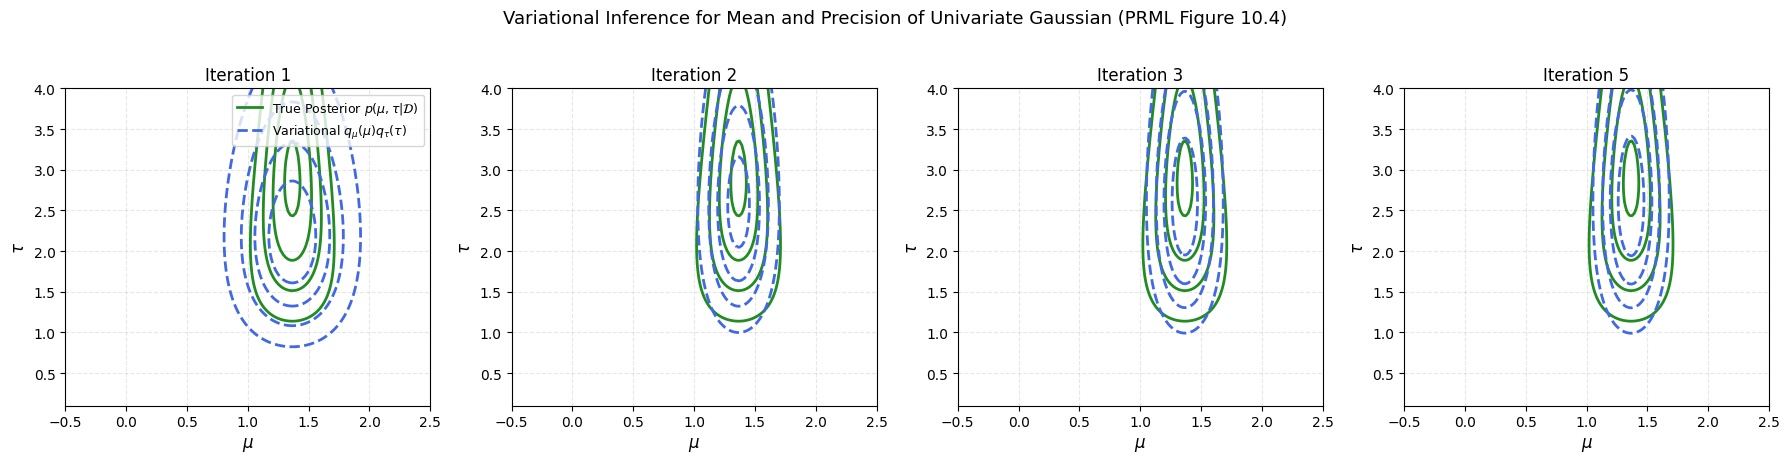

In [2]:
from common.variational_utils import variational_gaussian_1d
from scipy.stats import norm, gamma as gamma_scipy

# 人工データ生成 (真値: mu = 1.0, tau = 1.5)
np.random.seed(42)
N_pts = 10
mu_true = 1.0
tau_true = 1.5
X_data = np.random.normal(mu_true, 1.0 / np.sqrt(tau_true), N_pts)

# 変分推論の実行
history = variational_gaussian_1d(X_data, mu_0=0.0, lambda_0=0.0, a_0=0.0, b_0=0.0, max_iter=6)

# グリッド
mu_vals = np.linspace(-0.5, 2.5, 150)
tau_vals = np.linspace(0.1, 4.0, 150)
M_grid, T_grid = np.meshgrid(mu_vals, tau_vals)

# 真の結合事後分布 p(mu, tau | D) (ガウス・ガンマ分布)
# p(mu, tau | D) = N(mu | x_bar, (N*tau)^-1) * Gam(tau | a_N, b_N)
x_bar = np.mean(X_data)
s_sq = np.sum((X_data - x_bar)**2)
a_true = (N_pts) / 2.0
b_true = 0.5 * s_sq

P_true = np.zeros_like(M_grid)
for i in range(len(tau_vals)):
    t = tau_vals[i]
    p_tau = gamma_scipy.pdf(t, a=a_true, scale=1.0/b_true)
    p_mu = norm.pdf(mu_vals, loc=x_bar, scale=1.0/np.sqrt(N_pts * t))
    P_true[i, :] = p_tau * p_mu

# PRML Figure 10.4 のプロット (イテレーション 0, 1, 2, 5)
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
stages = [0, 1, 2, 4]

for idx, s in enumerate(stages):
    ax = axes[idx]
    mu_N, lambda_N, a_N, b_N = history[s]
    
    # 近似因数分解事後分布 Q(mu, tau) = q(mu) * q(tau)
    Q_approx = np.zeros_like(M_grid)
    q_mu = norm.pdf(mu_vals, loc=mu_N, scale=1.0/np.sqrt(lambda_N))
    q_tau = gamma_scipy.pdf(tau_vals, a=a_N, scale=1.0/b_N)
    for i in range(len(tau_vals)):
        Q_approx[i, :] = q_tau[i] * q_mu
        
    ax.contour(M_grid, T_grid, P_true, levels=5, colors='forestgreen', linewidths=2.0)
    ax.contour(M_grid, T_grid, Q_approx, levels=5, colors='royalblue', linestyles='--', linewidths=2.0)
    
    ax.set_title(f'Iteration {s+1}', fontsize=12)
    ax.set_xlabel(r'$\mu$', fontsize=12); ax.set_ylabel(r'$\tau$', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.3)

axes[0].plot([], [], color='forestgreen', lw=2, label=r'True Posterior $p(\mu, \tau|\mathcal{D})$')
axes[0].plot([], [], color='royalblue', linestyle='--', lw=2, label=r'Variational $q_\mu(\mu)q_\tau(\tau)$')
axes[0].legend(loc='upper right', fontsize=9)

plt.suptitle('Variational Inference for Mean and Precision of Univariate Gaussian (PRML Figure 10.4)', fontsize=13, y=1.02)
plt.tight_layout()
save_plot(fig, 'result', 'fig10_4_variational_gaussian_steps.png')
plt.show()